<a href="https://colab.research.google.com/github/ErickRC13/Investigaci-n-de-Operaciones-/blob/main/Networkx.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color="sky blue" > Network 1


**Alumno:** Erick Ramirez Cruz  
**Materia:** Investigación de Operaciones  
**Profesor:** Ricardo Medel Esquivel


## Problema de redes


En este cuaderno se  describe la solución de tres problemas de redes: **árbol de expansión mínima,ruta más corta,flujo máximo**

Este tutorial está basado en la documentación de:
[Network](https://network.org/en/)

In [33]:
import networkx as nx

In [34]:
import matplotlib.pyplot as plt

## <font color="royalblue"> 1) Árbol de expansión mínima
Determinaremos con el algoritmo de árbol de expansión mínima **versión no dirigida**  


### <font color="slategray">  Algoritmo de árbol de expansión mínima

Sea

$$
N=\{1,2,\ldots,n\}
$$

el conjunto de nodos de la red.

Se definen:

$$
C_k=\text{conjunto de nodos que se han conectado en forma permanente en la iteración }k
$$

$$
\overline{C}_k=\text{conjunto de nodos que todavía se deben conectar en forma permanente}
$$

El procedimiento es el siguiente:

**Paso 0.** Inicialmente,

$$
C_0=\varnothing,
\qquad
\overline{C}_0=N.
$$

**Paso 1.** Seleccionar cualquier nodo del conjunto de nodos no conectados,
por ejemplo el nodo \(i\), y hacer:

$$
C_1=\{i\},
\qquad
\overline{C}_1=N-\{i\}.
$$

Después se toma:

$$
k=2.
$$

**Paso general $k$.** Seleccionar un nodo $j^*$ del conjunto de nodos no conectados
$\overline{C}_{k-1}$, de manera que el arco más corto hacia $j^*$ provenga de algún
nodo perteneciente al conjunto conectado $C_{k-1}$.

Entonces se actualizan los conjuntos:

$$
C_k=C_{k-1}+\{j^*\}
$$

$$
\overline{C}_k=\overline{C}_{k-1}-\{j^*\}.
$$

El procedimiento continúa hasta que:

$$
\overline{C}_k=\varnothing.
$$

En cada iteración se selecciona la arista de menor longitud que conecta un nodo
ya incorporado al árbol con un nodo que todavía no ha sido conectado.

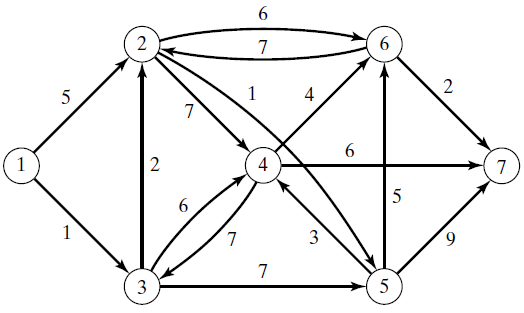

In [35]:
from IPython.display import Image, display

display(Image(filename="actividad_1_a.png"))

In [36]:
# Posiciones de los nodos
pos = {
    1: (0.0, 1.0),
    2: (1.6, 2.0),
    3: (1.6, 0.0),
    4: (3.6, 1.0),
    6: (5.6, 2.0),
    5: (5.6, 0.0),
    7: (7.2, 1.0)
}

# (nodo1, nodo2, peso, curvatura)
aristas_arbol = [
    (4, 5, 3, 0.00),     # Paso 1: recta
    (2, 5, 1, -0.22),    # Paso 2: CURVA
    (2, 3, 2, 0.00),     # Paso 3: recta
    (3, 1, 1, 0.00),     # Paso 4: recta
    (4, 6, 4, 0.00),     # Paso 5: recta
    (6, 7, 2, 0.00)      # Paso 6: recta
]

longitudes = [0, 3, 4, 6, 7, 11, 13]

In [37]:
def dibujar_arbol(paso):

    G = nx.Graph()

    if paso == 0:
        G.add_node(4)

    else:
        for u, v, peso, curva in aristas_arbol[:paso]:
            G.add_edge(u, v, weight=peso)

    plt.figure(figsize=(9, 5))


    nx.draw_networkx_nodes(
        G,
        pos,
        node_size=900,
        node_color="lightblue",
        edgecolors="black",
        linewidths=1.5
    )


    nx.draw_networkx_labels(
        G,
        pos,
        font_size=12,
        font_weight="bold"
    )


    if paso > 0:

        for u, v, peso, curva in aristas_arbol[:paso]:

            nx.draw_networkx_edges(
                G,
                pos,
                edgelist=[(u, v)],


                edge_color="green",
                width=3,


                arrows=True,


                arrowstyle="-",


                connectionstyle=f"arc3,rad={curva}"
            )



            x1, y1 = pos[u]
            x2, y2 = pos[v]

            xm = (x1 + x2) / 2
            ym = (y1 + y2) / 2


            if curva != 0:

                dx = x2 - x1
                dy = y2 - y1

                distancia = (dx**2 + dy**2)**0.5

                xm += (-dy / distancia) * curva * 1.4
                ym += ( dx / distancia) * curva * 1.4

            plt.text(
                xm,
                ym,
                str(peso),
                fontsize=11,
                color="green",
                fontweight="bold",
                horizontalalignment="center",
                verticalalignment="center",
                bbox=dict(
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.8
                )
            )



    plt.title(
        f"Paso {paso} - Longitud acumulada L = {longitudes[paso]}"
    )

    plt.axis("off")
    plt.show()

### Paso 0

El conjunto de nodos es

$$
N=\{1,2,3,4,5,6,7\}.
$$

Inicialmente,


$$
C_0=\varnothing
$$

$$
\overline{C}_0=\{1,2,3,4,5,6,7\}.
$$

Se selecciona como nodo inicial el nodo 4.

La longitud acumulada inicialmente es

$$
l=0.
$$

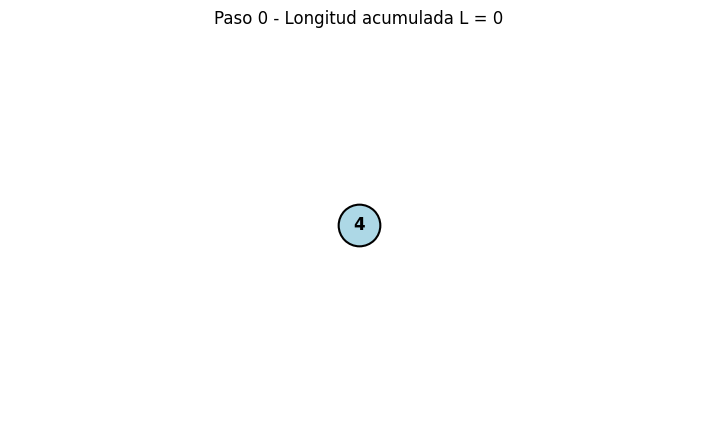

In [38]:
dibujar_arbol(0)

### Paso 1

Partiendo del nodo 4, las conexiones disponibles son:

$$
4-2=7,\qquad
4-3=6,\qquad
$$

$$
4-5=3,\qquad
4-6=4,\qquad
4-7=6.
$$

La arista de menor peso es

$$
\boxed{4-5=3}.
$$

Por lo tanto,

$$
C_1=\{4,5\}
$$

$$
\overline{C}_1=\{1,2,3,6,7\}.
$$

La longitud acumulada es

$$
l=0+3=3.
$$

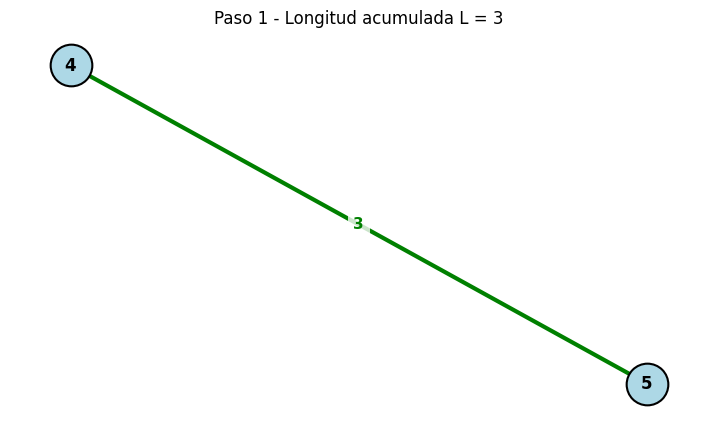

In [39]:
dibujar_arbol(1)

### Paso 2

Ahora,

$$
C_1=\{4,5\}
$$

y

$$
\overline{C}_1=\{1,2,3,6,7\}.
$$

Se revisan las aristas que conectan los nodos de $C_1$ con los nodos que todavía no pertenecen al árbol.

La menor arista disponible es

$$
\boxed{5-2=1}.
$$

Por lo tanto,

$$
C_2=\{4,5,2\}
$$

$$
\overline{C}_2=\{1,3,6,7\}.
$$

La longitud acumulada es

$$
l=3+1=4.
$$

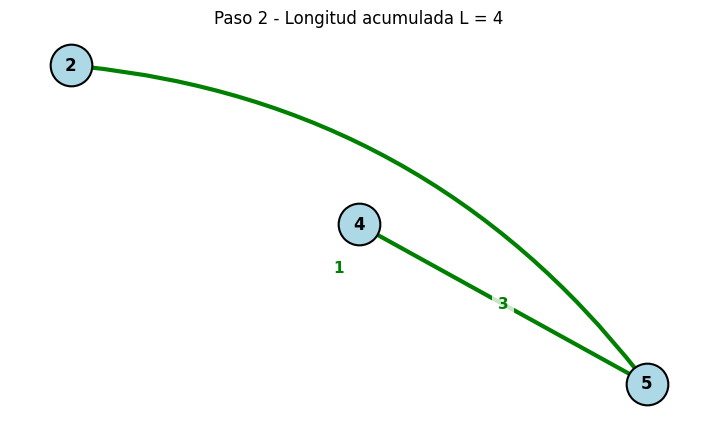

In [40]:
dibujar_arbol(2)

### Paso 3

Actualmente,

$$
C_2=\{4,5,2\}
$$

$$
\overline{C}_2=\{1,3,6,7\}.
$$

La menor arista disponible para incorporar un nuevo nodo es

$$
\boxed{2-3=2}.
$$

Por lo tanto,

$$
C_3=\{4,5,2,3\}
$$

$$
\overline{C}_3=\{1,6,7\}.
$$

La longitud acumulada es

$$
l=4+2=6.
$$

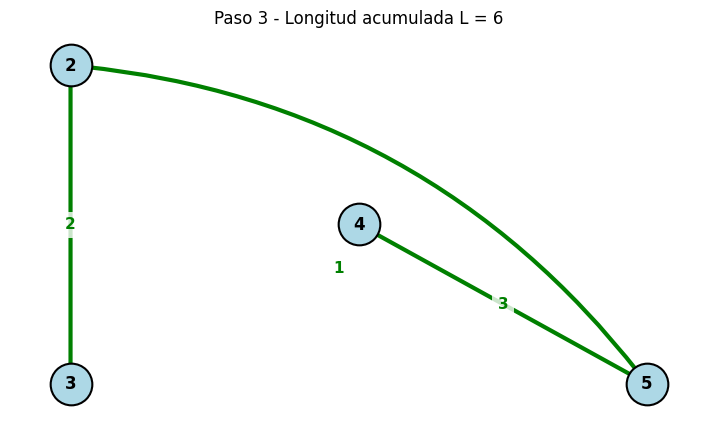

In [41]:
dibujar_arbol(3)

### Paso 4

Actualmente,

$$
C_3=\{4,5,2,3\}
$$

$$
\overline{C}_3=\{1,6,7\}.
$$

La menor arista disponible es

$$
\boxed{3-1=1}.
$$

Por lo tanto,

$$
C_4=\{4,5,2,3,1\}
$$

$$
\overline{C}_4=\{6,7\}.
$$

La longitud acumulada es

$$
l=6+1=7.
$$

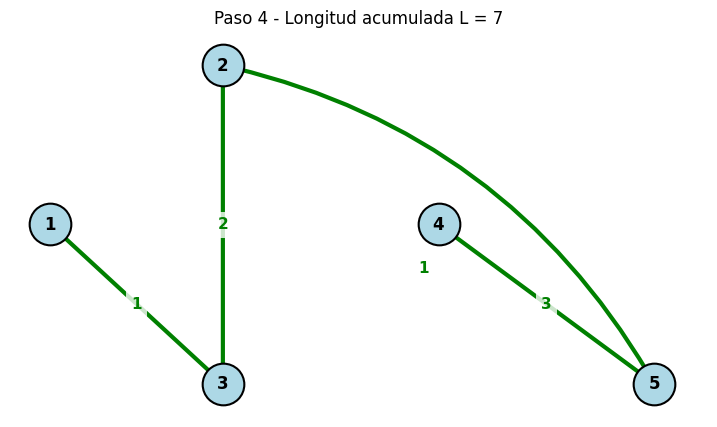

In [42]:
dibujar_arbol(4)

### Paso 5

Actualmente,

$$
C_4=\{4,5,2,3,1\}
$$

$$
\overline{C}_4=\{6,7\}.
$$

Entre las conexiones disponibles se tienen

$$
4-6=4,\qquad
5-6=5,\qquad
4-7=6,\qquad
5-7=9.
$$

La menor es

$$
\boxed{4-6=4}.
$$

Entonces,

$$
C_5=\{4,5,2,3,1,6\}
$$

$$
\overline{C}_5=\{7\}.
$$

La longitud acumulada es

$$
l=7+4=11.
$$

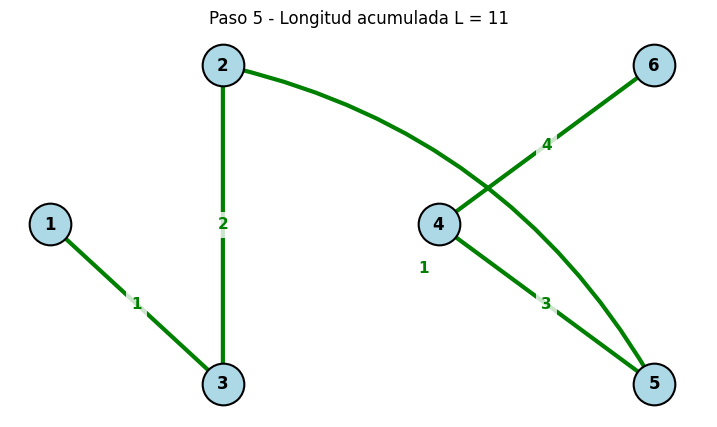

In [43]:
dibujar_arbol(5)

### Paso 6

Sólo falta incorporar el nodo 7.

Las conexiones disponibles hacia este nodo son

$$
4-7=6,\qquad
5-7=9,\qquad
6-7=2.
$$

La menor es

$$
\boxed{6-7=2}.
$$

Por lo tanto,

$$
C_6=\{1,2,3,4,5,6,7\}
$$

y

$$
\overline{C}_6=\varnothing.
$$

La longitud acumulada final es

$$
l=11+2=13.
$$

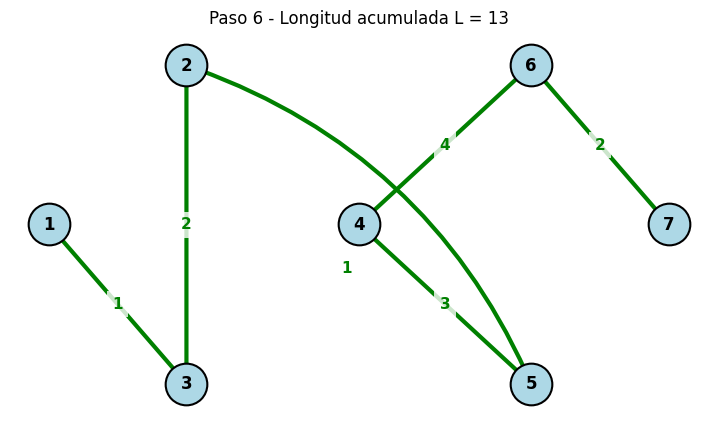

In [44]:
dibujar_arbol(6)

## Resultado final

Las aristas que forman el árbol de expansión mínima

$$
(4,5),\quad
(5,2),\quad
(2,3),\quad
(3,1),\quad
(4,6),\quad
(6,7).
$$

Así

$$
l_{\min}
=
3+1+2+1+4+2
$$

y finalmente

$$
\boxed{l_{\min}=13}.
$$



### Comprobación con NetworkX

Para verificar el resultado obtenido manualmente, se utiliza la función
`minimum_spanning_tree()` de NetworkX.

El resultado manual fue:

$$
\boxed{L_{\min}=13}
$$

In [45]:
G1_comprobacion = nx.Graph()

aristas_completas1 = [
    (1, 2, 5),
    (1, 3, 1),
    (2, 3, 2),
    (2, 4, 7),
    (2, 5, 1),
    (2, 6, 6),
    (3, 4, 6),
    (3, 5, 7),
    (4, 5, 3),
    (4, 6, 4),
    (4, 7, 6),
    (5, 6, 5),
    (5, 7, 9),
    (6, 7, 2)
]

G1_comprobacion.add_weighted_edges_from(aristas_completas1)


T1 = nx.minimum_spanning_tree(
    G1_comprobacion,
    weight="weight"
)


peso_total1 = sum(
    datos["weight"]
    for u, v, datos in T1.edges(data=True)
)

print("Aristas del árbol de expansión mínima:")

for u, v, datos in T1.edges(data=True):
    print(f"{u} - {v}: {datos['weight']}")

print("\nPeso total:")
print(peso_total1)

Aristas del árbol de expansión mínima:
1 - 3: 1
2 - 5: 1
2 - 3: 2
4 - 5: 3
4 - 6: 4
6 - 7: 2

Peso total:
13


### Verificación

El procedimiento manual y NetworkX proporcionan el mismo costo total:

$$
\boxed{L_{\min}=13}
$$

Por lo tanto, se verifica que el árbol obtenido es un árbol de expansión mínima.

## <font color="seagreen"> 2) Ruta más corta
Aplicando el algoritmo de Dijkstra, se determinará la ruta de menor distancia desde el nodo \(1\) hasta el nodo \(7\)

### <font color="slategray"> Algoritmo de la ruta más corta

El procedimiento identifica sucesivamente los nodos más cercanos al origen.
Los nodos cuya distancia mínima ya ha sido determinada se denominan
**nodos resueltos**; los demás se consideran **nodos no resueltos**.

**Objetivo de la $n$-ésima iteración.**

Encontrar el $n$-ésimo nodo más cercano al origen.

El procedimiento continúa para

$$
n=1,2,\ldots
$$

hasta que el nodo seleccionado sea el nodo destino.

**Datos de la $n$-ésima iteración.**

Al comenzar una iteración ya se conocen los nodos resueltos obtenidos en las
iteraciones anteriores, junto con:

- su distancia mínima desde el origen;
- la ruta más corta encontrada hasta cada uno de ellos;
- su última conexión.

**Candidatos para el $n$-ésimo nodo más cercano.**

Se consideran las conexiones que parten de los nodos resueltos hacia los nodos
no resueltos.

Para cada candidato se calcula la distancia total:

$$
D_j=D_i+d_{ij}
$$

donde:

$$
D_i=\text{distancia mínima desde el origen hasta el nodo resuelto }i
$$

y

$$
d_{ij}=\text{distancia del arco que conecta }i\text{ con }j.
$$

**Cálculo del $n$-ésimo nodo más cercano.**

Se comparan las distancias totales de todos los candidatos y se selecciona la
menor:

$$
D_{j^*}=\min\{D_i+d_{ij}\}.
$$

El nodo $j^*$ se convierte en un nuevo nodo resuelto y se registra:

- el nodo seleccionado;
- su distancia mínima;
- su última conexión.

El procedimiento se repite hasta que el nodo destino se convierta en un nodo
resuelto.

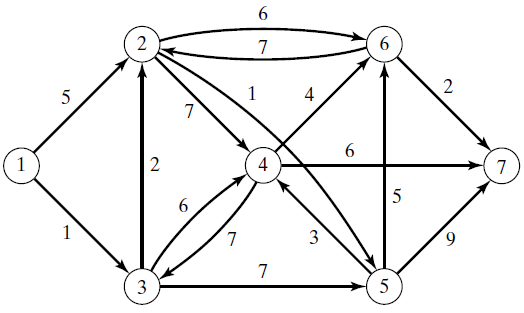

In [46]:
from IPython.display import Image, display

display(Image(filename="actividad_1_a.png"))

In [47]:
G2 = nx.DiGraph()

aristas2 = [
    (1, 2, 5),
    (1, 3, 1),

    (3, 2, 2),

    (2, 6, 6),
    (6, 2, 7),

    (2, 4, 7),
    (2, 5, 1),

    (3, 4, 6),
    (4, 3, 7),

    (3, 5, 7),

    (4, 6, 4),
    (4, 7, 6),

    (5, 4, 3),
    (5, 6, 5),
    (5, 7, 9),

    (6, 7, 2)
]


G2.add_weighted_edges_from(aristas2)

print("Red del Ejercicio 2 creada correctamente.")
print("Número de nodos:", G2.number_of_nodes())
print("Número de arcos:", G2.number_of_edges())

Red del Ejercicio 2 creada correctamente.
Número de nodos: 7
Número de arcos: 16


In [48]:
from IPython.display import HTML, display

tabla_mi_cuaderno = """
<style>
    .tabla-cuaderno {
        border-collapse: collapse;
        width: 100%;
        font-size: 14px;
        text-align: center;
    }

    .tabla-cuaderno th {
        border: 2px solid #8e44ad;
        padding: 8px;
        background-color: #f3e5f5;
    }

    .tabla-cuaderno td {
        border: 1.5px solid #b565c0;
        padding: 7px;
        vertical-align: middle;
    }

    .tabla-cuaderno .izquierda {
        text-align: left;
    }
</style>

<table class="tabla-cuaderno">

<tr>
    <th>n</th>
    <th>Nodo resuelto conectado directamente<br>a nodo no resuelto</th>
    <th>Nodo no resuelto más cercano conectado</th>
    <th>Distancia total involucrada</th>
    <th>n-ésimo nodo más cercano</th>
    <th>Distancia mínima</th>
    <th>Última conexión</th>
</tr>

<!-- ITERACIÓN 1 -->
<tr>
    <td>1</td>
    <td>1</td>
    <td>3</td>
    <td>1</td>
    <td>3</td>
    <td>1</td>
    <td>1 - 3</td>
</tr>

<!-- ITERACIÓN 2 -->
<tr>
    <td rowspan="2">2</td>
    <td>1</td>
    <td>2</td>
    <td>5</td>
    <td rowspan="2">2</td>
    <td rowspan="2">3</td>
    <td rowspan="2">3 - 2</td>
</tr>

<tr>
    <td>3</td>
    <td>2</td>
    <td>1 + 2 = 3</td>
</tr>

<!-- ITERACIÓN 3 -->
<tr>
    <td rowspan="2">3</td>
    <td>2</td>
    <td>5</td>
    <td>3 + 1 = 4</td>
    <td rowspan="2">5</td>
    <td rowspan="2">4</td>
    <td rowspan="2">2 - 5</td>
</tr>

<tr>
    <td>3</td>
    <td>4</td>
    <td>1 + 6 = 7</td>
</tr>

<!-- ITERACIÓN 4 -->
<tr>
    <td rowspan="3">4</td>
    <td>2</td>
    <td>6</td>
    <td>3 + 6 = 9</td>
    <td></td>
    <td></td>
    <td></td>
</tr>

<tr>
    <td>3</td>
    <td>4</td>
    <td>1 + 6 = 7</td>
    <td>4</td>
    <td>7</td>
    <td>3 - 4</td>
</tr>

<tr>
    <td>5</td>
    <td>4</td>
    <td>4 + 3 = 7</td>
    <td>4</td>
    <td>7</td>
    <td>5 - 4</td>
</tr>

<!-- ITERACIÓN 5 -->
<tr>
    <td rowspan="3">5</td>
    <td>2</td>
    <td>6</td>
    <td>3 + 6 = 9</td>
    <td>6</td>
    <td>9</td>
    <td>2 - 6</td>
</tr>

<tr>
    <td>4</td>
    <td>6</td>
    <td>7 + 4 = 11</td>
    <td></td>
    <td></td>
    <td></td>
</tr>

<tr>
    <td>5</td>
    <td>6</td>
    <td>4 + 5 = 9</td>
    <td>6</td>
    <td>9</td>
    <td>5 - 6</td>
</tr>

<!-- ITERACIÓN 6 -->
<tr>
    <td rowspan="3">6</td>
    <td>4</td>
    <td>7</td>
    <td>7 + 6 = 13</td>
    <td></td>
    <td></td>
    <td></td>
</tr>

<tr>
    <td>5</td>
    <td>7</td>
    <td>4 + 9 = 13</td>
    <td></td>
    <td></td>
    <td></td>
</tr>

<tr>
    <td>6</td>
    <td>7</td>
    <td>9 + 2 = 11</td>
    <td>7</td>
    <td>11</td>
    <td>6 - 7</td>
</tr>

</table>
"""

display(HTML(tabla_mi_cuaderno))

### Ruta óptima

De la tabla se obtiene:

$$
7 \leftarrow 6
$$

$$
6 \leftarrow 2
$$

$$
2 \leftarrow 3
$$

$$
3 \leftarrow 1
$$


Entonces, la ruta más corta del nodo \(1\) al nodo \(7\) es:

$$
\boxed{1 \rightarrow 3 \rightarrow 2 \rightarrow 6 \rightarrow 7}
$$

con una distancia mínima de:

$$
\boxed{11}
$$

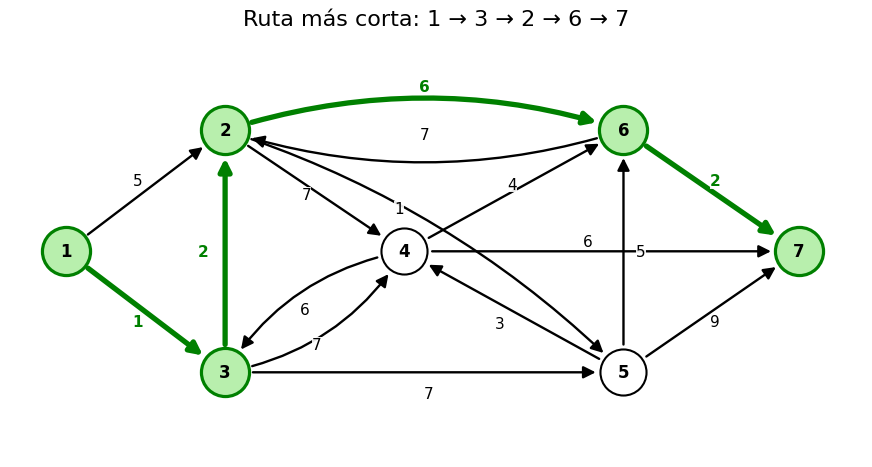

In [49]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch


G2 = nx.DiGraph()

aristas2 = [
    (1, 2, 5),
    (1, 3, 1),

    (3, 2, 2),

    (2, 6, 6),
    (6, 2, 7),

    (2, 4, 7),
    (2, 5, 1),

    (3, 4, 6),
    (4, 3, 7),

    (3, 5, 7),

    (4, 6, 4),
    (4, 7, 6),

    (5, 4, 3),
    (5, 6, 5),
    (5, 7, 9),

    (6, 7, 2)
]

G2.add_weighted_edges_from(aristas2)


ruta_optima2 = [1, 3, 2, 6, 7]

aristas_ruta2 = {
    (1, 3),
    (3, 2),
    (2, 6),
    (6, 7)
}


pos2 = {
    1: (0.0, 1.0),

    2: (2.0, 2.0),
    3: (2.0, 0.0),

    4: (4.25, 1.0),

    6: (7.0, 2.0),
    5: (7.0, 0.0),

    7: (9.2, 1.0)
}




curvas2 = {

    (2, 6): -0.16,
    (6, 2): -0.16,

    (3, 4): 0.22,
    (4, 3): 0.22
}



pos_pesos2 = {


    (1, 2): (0.90, 1.58),
    (1, 3): (0.90, 0.42),


    (3, 2): (1.72, 1.00),


    (2, 6): (4.50, 2.36),
    (6, 2): (4.50, 1.96),

    (2, 4): (3.02, 1.47),


    (2, 5): (4.18, 1.35),


    (3, 4): (3.00, 0.52),
    (4, 3): (3.15, 0.23),


    (3, 5): (4.55, -0.18),


    (4, 6): (5.60, 1.55),
    (4, 7): (6.55, 1.08),


    (5, 4): (5.45, 0.40),
    (5, 6): (7.22, 1.00),
    (5, 7): (8.15, 0.42),


    (6, 7): (8.15, 1.58)
}


fig, ax = plt.subplots(figsize=(11, 5.5))


for u, v, peso in aristas2:



    if (u, v) == (2, 5):
        curva = -0.12
    else:
        curva = curvas2.get((u, v), 0.0)



    if (u, v) in aristas_ruta2:

        color = "green"
        grosor = 3.8

    else:

        color = "black"
        grosor = 1.7


    flecha = FancyArrowPatch(

        posA=pos2[u],
        posB=pos2[v],

        arrowstyle="-|>",
        mutation_scale=18,

        connectionstyle=f"arc3,rad={curva}",

        linewidth=grosor,
        color=color,


        shrinkA=20,
        shrinkB=20,

        zorder=1
    )

    ax.add_patch(flecha)


nx.draw_networkx_nodes(
    G2,
    pos2,

    nodelist=[4, 5],

    node_size=1100,
    node_color="white",

    edgecolors="black",
    linewidths=1.5,

    ax=ax
)


nx.draw_networkx_nodes(
    G2,
    pos2,

    nodelist=ruta_optima2,

    node_size=1200,
    node_color="#b8efad",

    edgecolors="green",
    linewidths=2.3,

    ax=ax
)


nx.draw_networkx_labels(
    G2,
    pos2,

    font_size=12,
    font_weight="bold",

    ax=ax
)


for u, v, peso in aristas2:

    x, y = pos_pesos2[(u, v)]

    if (u, v) in aristas_ruta2:

        color = "green"
        negrita = "bold"

    else:

        color = "black"
        negrita = "normal"


    ax.text(

        x,
        y,
        str(peso),

        fontsize=11,
        fontweight=negrita,
        color=color,

        horizontalalignment="center",
        verticalalignment="center",

        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.90,
            pad=0.10
        ),

        zorder=5
    )

ax.set_title(
    "Ruta más corta: 1 → 3 → 2 → 6 → 7",
    fontsize=16
)


ax.set_xlim(-0.7, 10.0)
ax.set_ylim(-0.7, 2.8)

ax.axis("off")

plt.show()

### Comprobación con NetworkX

Utilizamos NetworkX para verificar el resultado.

La distancia mínima obtenida fue:

$$
\boxed{d_{\min}=11}
$$

con una ruta óptima:

$$
\boxed{1\rightarrow3\rightarrow2\rightarrow6\rightarrow7}
$$

In [50]:
distancia_minima2 = nx.shortest_path_length(
    G2,
    source=1,
    target=7,
    weight="weight",
    method="dijkstra"
)


ruta_networkx2 = nx.shortest_path(
    G2,
    source=1,
    target=7,
    weight="weight",
    method="dijkstra"
)

print("Ruta más corta obtenida por NetworkX:")
print(" → ".join(map(str, ruta_networkx2)))

print("\nDistancia mínima:")
print(distancia_minima2)

Ruta más corta obtenida por NetworkX:
1 → 3 → 2 → 6 → 7

Distancia mínima:
11


In [51]:
rutas_optimas2 = list(
    nx.all_shortest_paths(
        G2,
        source=1,
        target=7,
        weight="weight",
        method="dijkstra"
    )
)

print("Rutas óptimas encontradas:\n")

for i, ruta in enumerate(rutas_optimas2, start=1):
    print(f"Ruta {i}: " + " → ".join(map(str, ruta)))

print("\nDistancia mínima:", distancia_minima2)

Rutas óptimas encontradas:

Ruta 1: 1 → 3 → 2 → 6 → 7
Ruta 2: 1 → 3 → 2 → 5 → 6 → 7

Distancia mínima: 11


### Resultado

La distancia mínima entre los nodos 1 y 7 es:

$$
\boxed{d_{\min}=11}
$$

Una ruta óptima es:

$$
\boxed{1\rightarrow3\rightarrow2\rightarrow6\rightarrow7}
$$

Tenemos un empate

$$
\boxed{1\rightarrow3\rightarrow2\rightarrow5\rightarrow6\rightarrow7}
$$

ya que:

$$
1+2+1+5+2=11
$$

Por lo tanto, ambas rutas son óptimas.

## <font color="firebrick"> 3) Flujo máximo
Para resolver el problema se utiliza el **algoritmo de trayectorias de aumento**



### <font color="slategray"> Algoritmo de la trayectoria aumentada

El procedimiento se realiza sobre la **red residual**.

**Paso 1. Identificar una trayectoria de aumento.**

Se busca una trayectoria dirigida desde el nodo origen hasta el nodo destino
en la cual todos los arcos tengan capacidad residual estrictamente positiva.

Si no existe ninguna trayectoria de aumento, el flujo actual corresponde al
**flujo máximo**.

**Paso 2. Determinar la capacidad residual de la trayectoria.**

Para la trayectoria seleccionada se calcula:

$$
c^*=\min\{\text{capacidades residuales de los arcos de la trayectoria}\}.
$$

El valor $c^*$ representa la cantidad máxima de flujo adicional que puede
enviarse por esa trayectoria.

El flujo total se actualiza mediante:

$$
F_{\text{nuevo}}=F_{\text{anterior}}+c^*.
$$

**Paso 3. Actualizar la red residual.**

Para cada arco perteneciente a la trayectoria de aumento:

- se disminuye en $c^*$ la capacidad residual en el sentido de la trayectoria;
- se aumenta en $c^*$ la capacidad residual del arco en el sentido contrario.

Es decir, si se utiliza el arco $i\rightarrow j$:

$$
r_{ij}^{\,\text{nuevo}}
=
r_{ij}^{\,\text{anterior}}-c^*
$$

y

$$
r_{ji}^{\,\text{nuevo}}
=
r_{ji}^{\,\text{anterior}}+c^*.
$$

Después de actualizar la red residual, se regresa al **Paso 1** y se busca una
nueva trayectoria de aumento.

El procedimiento termina cuando ya no existe ninguna trayectoria dirigida
desde el origen hasta el destino con capacidad residual positiva en todos sus
arcos.

In [52]:
G3 = nx.DiGraph()


capacidades3 = [
    (1, 3, 14),
    (3, 1, 0),

    (1, 2, 8),
    (2, 1, 0),

    (1, 5, 4),
    (5, 1, 0),

    (2, 3, 5),
    (3, 2, 10),

    (3, 4, 9),
    (4, 3, 7),

    (3, 5, 10),
    (5, 3, 0),

    (2, 4, 7),
    (4, 2, 6),

    (2, 5, 6),
    (5, 2, 0),

    (4, 5, 5),
    (5, 4, 0)
]


for u, v, capacidad in capacidades3:
    G3.add_edge(u, v, capacity=capacidad)


pos3 = {
    1: (0, 1),
    3: (3, 2.5),
    2: (3, 0),
    4: (6, 0),
    5: (8.5, 1)
}



conexiones3 = [
    (1, 3),
    (1, 2),
    (1, 5),
    (2, 3),
    (3, 4),
    (3, 5),
    (2, 4),
    (2, 5),
    (4, 5)
]




def dibujar_red_residual3(residual, titulo, flujo_total=0, trayectoria=None):

    plt.figure(figsize=(11, 5.5))



    nx.draw_networkx_nodes(
        G3,
        pos3,
        node_size=1200,
        node_color="white",
        edgecolors="black",
        linewidths=1.5
    )

    nx.draw_networkx_labels(
        G3,
        pos3,
        font_size=12,
        font_weight="bold"
    )




    aristas_trayectoria = set()

    if trayectoria is not None:

        for i in range(len(trayectoria) - 1):

            u = trayectoria[i]
            v = trayectoria[i + 1]

            aristas_trayectoria.add((u, v))




    for u, v in conexiones3:

        if ((u, v) in aristas_trayectoria or
            (v, u) in aristas_trayectoria):

            color = "green"
            grosor = 3.5

        else:

            color = "black"
            grosor = 1.5


        nx.draw_networkx_edges(
            G3,
            pos3,
            edgelist=[(u, v)],
            width=grosor,
            edge_color=color,
            arrows=False
        )



    for u, v in conexiones3:

        x1, y1 = pos3[u]
        x2, y2 = pos3[v]


        xu = 0.72*x1 + 0.28*x2
        yu = 0.72*y1 + 0.28*y2


        xv = 0.28*x1 + 0.72*x2
        yv = 0.28*y1 + 0.72*y2

        cap_uv = residual[(u, v)]
        cap_vu = residual[(v, u)]


        plt.text(
            xu,
            yu,
            str(cap_uv),
            fontsize=11,
            color="red",
            fontweight="bold",
            horizontalalignment="center",
            verticalalignment="center",
            bbox=dict(
                facecolor="white",
                edgecolor="none",
                alpha=0.85,
                pad=0.15
            )
        )


        plt.text(
            xv,
            yv,
            str(cap_vu),
            fontsize=11,
            color="red",
            fontweight="bold",
            horizontalalignment="center",
            verticalalignment="center",
            bbox=dict(
                facecolor="white",
                edgecolor="none",
                alpha=0.85,
                pad=0.15
            )
        )



    plt.text(
        -0.8,
        1,
        f"Origen\nF = {flujo_total}",
        fontsize=11,
        horizontalalignment="center",
        verticalalignment="center"
    )

    plt.text(
        9.4,
        1,
        f"Destino\nF = {flujo_total}",
        fontsize=11,
        horizontalalignment="center",
        verticalalignment="center"
    )


    plt.title(titulo, fontsize=15)

    plt.xlim(-1.5, 10.2)
    plt.ylim(-0.8, 3.3)

    plt.axis("off")
    plt.show()

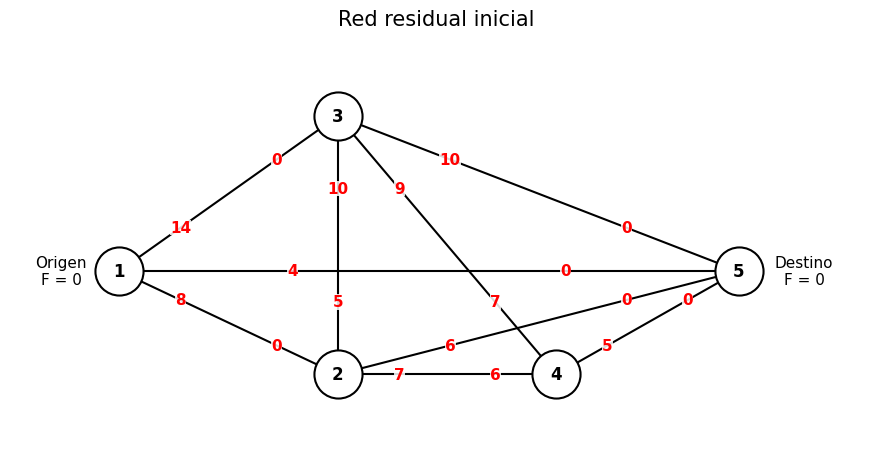

In [53]:
residual3 = {}
for u, v, capacidad in capacidades3:
    residual3[(u, v)] = capacidad


dibujar_red_residual3(
    residual3,
    "Red residual inicial",
    flujo_total=0
)

Las trayectorias seleccionadas son:
$$
1\rightarrow3\rightarrow5
$$

$$
1\rightarrow2\rightarrow4\rightarrow5
$$

$$
1\rightarrow3\rightarrow2\rightarrow5
$$

$$
1\rightarrow5
$$

$$
1\rightarrow2\rightarrow5
$$

En cada iteración se determina $c^*$ y se actualiza la red residual.

ITERACIÓN 1
Trayectoria: 1 → 3 → 5
Capacidades residuales: [14, 10]
c* = 10
Flujo acumulado = 10


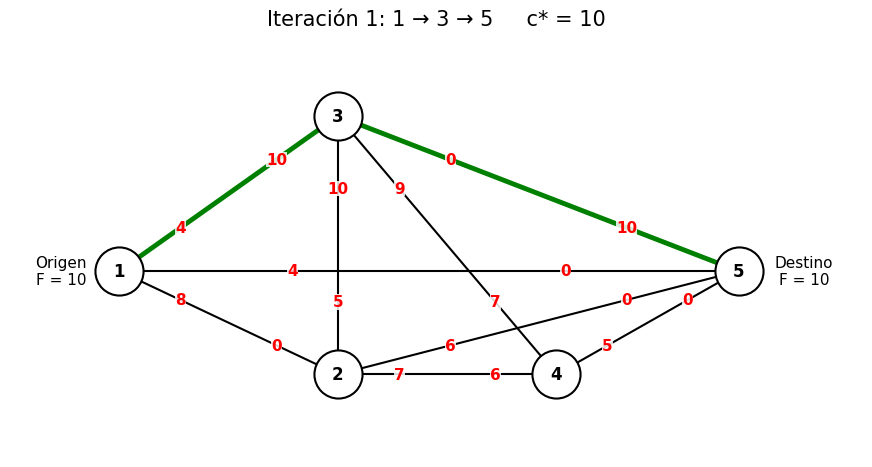

ITERACIÓN 2
Trayectoria: 1 → 2 → 4 → 5
Capacidades residuales: [8, 7, 5]
c* = 5
Flujo acumulado = 15


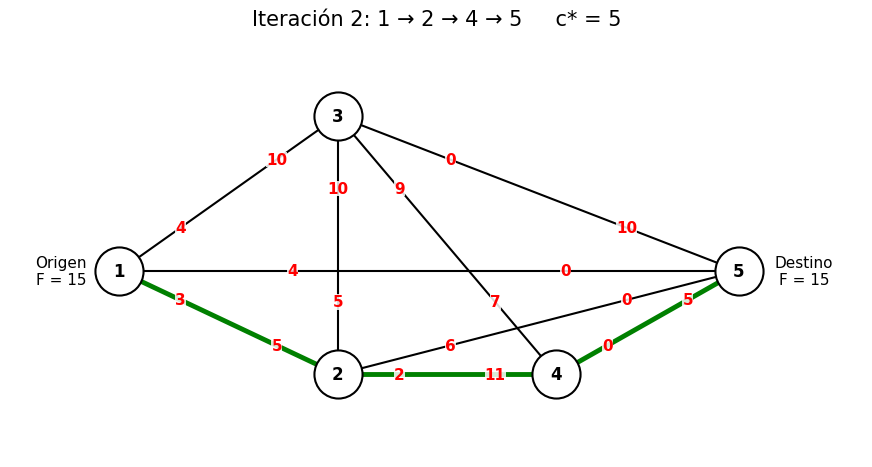

ITERACIÓN 3
Trayectoria: 1 → 3 → 2 → 5
Capacidades residuales: [4, 10, 6]
c* = 4
Flujo acumulado = 19


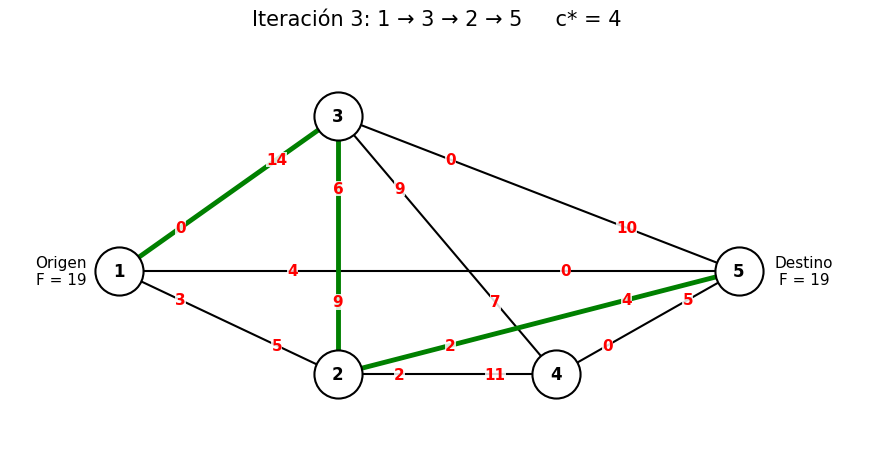

ITERACIÓN 4
Trayectoria: 1 → 5
Capacidades residuales: [4]
c* = 4
Flujo acumulado = 23


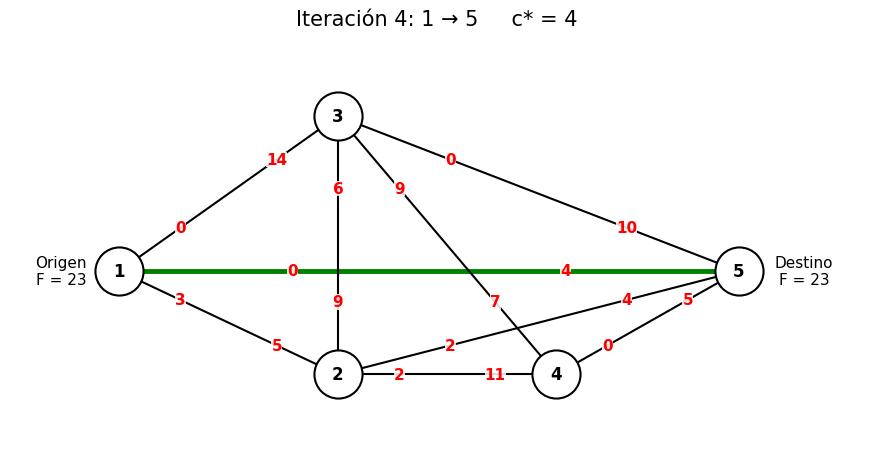

ITERACIÓN 5
Trayectoria: 1 → 2 → 5
Capacidades residuales: [3, 2]
c* = 2
Flujo acumulado = 25


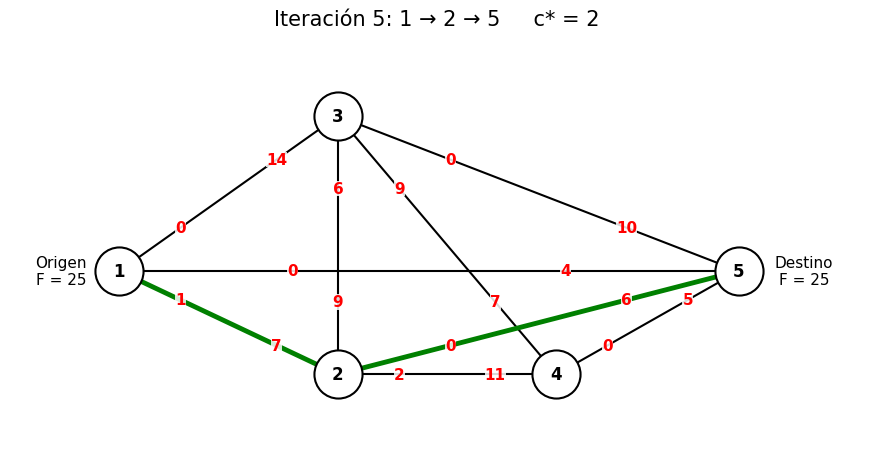

In [30]:
trayectorias3 = [
    [1, 3, 5],
    [1, 2, 4, 5],
    [1, 3, 2, 5],
    [1, 5],
    [1, 2, 5]
]




residual3 = {}

for u, v, capacidad in capacidades3:
    residual3[(u, v)] = capacidad


flujo_total3 = 0





for i, trayectoria in enumerate(trayectorias3, start=1):

    capacidades_camino = []



    for j in range(len(trayectoria) - 1):

        u = trayectoria[j]
        v = trayectoria[j + 1]

        capacidades_camino.append(
            residual3[(u, v)]
        )



    c_estrella = min(capacidades_camino)



    flujo_total3 += c_estrella




    print("=" * 55)

    print(f"ITERACIÓN {i}")

    print(
        "Trayectoria:",
        " → ".join(map(str, trayectoria))
    )

    print(
        "Capacidades residuales:",
        capacidades_camino
    )

    print(
        "c* =",
        c_estrella
    )

    print(
        "Flujo acumulado =",
        flujo_total3
    )

    print("=" * 55)




    for j in range(len(trayectoria) - 1):

        u = trayectoria[j]
        v = trayectoria[j + 1]


        residual3[(u, v)] -= c_estrella


        residual3[(v, u)] += c_estrella




    dibujar_red_residual3(
        residual3,
        f"Iteración {i}: "
        + " → ".join(map(str, trayectoria))
        + f"     c* = {c_estrella}",
        flujo_total=flujo_total3,
        trayectoria=trayectoria
    )

Las capacidades de aumento obtenidas fueron:

$$
c_1^*=10
$$

$$
c_2^*=5
$$

$$
c_3^*=4
$$

$$
c_4^*=4
$$

$$
c_5^*=2
$$

En la red residual final ya no existe ninguna trayectoria de aumento desde el nodo
$1$ hasta el nodo $5$.

Por lo tanto:

$$
\boxed{F_{\max}=25}
$$

In [54]:
print("Capacidades residuales de los arcos que entran al nodo 5:\n")

print("1 → 5 =", residual3[(1, 5)])
print("2 → 5 =", residual3[(2, 5)])
print("3 → 5 =", residual3[(3, 5)])
print("4 → 5 =", residual3[(4, 5)])

Capacidades residuales de los arcos que entran al nodo 5:

1 → 5 = 4
2 → 5 = 6
3 → 5 = 10
4 → 5 = 5


## Comprobación con NetworkX

Para verificar el resultado obtenido mediante el algoritmo de trayectorias de aumento,
se utiliza la función de flujo máximo de NetworkX.

El resultado manual fue:

$$
\boxed{F_{\max}=25}
$$

In [55]:

valor_flujo3, flujo3 = nx.maximum_flow(
    G3,
    1,
    5,
    capacity="capacity"
)

print("Flujo máximo obtenido por NetworkX:")
print(valor_flujo3)

print("\nDistribución del flujo:")
for u in flujo3:
    for v in flujo3[u]:
        if flujo3[u][v] > 0:
            print(f"{u} → {v}: {flujo3[u][v]}")

Flujo máximo obtenido por NetworkX:
25

Distribución del flujo:
1 → 3: 13
1 → 2: 8
1 → 5: 4
3 → 4: 5
3 → 5: 10
2 → 3: 2
2 → 5: 6
4 → 5: 5


### Verificación

El procedimiento manual mediante trayectorias de aumento produjo:

$$
F_{\max}=25
$$

NetworkX también obtiene:

$$
F_{\max}=25
$$

Ambos métodos coinciden.

## Resultados finales

Los resultados obtenidos y verificados con NetworkX son:

$$
\boxed{L_{\min}=13}
$$

$$
\boxed{d_{\min}=11}
$$

$$
\boxed{F_{\max}=25}
$$